In [2]:

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ All imports done")
print(f"🖥️  Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

✅ All imports done
🖥️  Device: cpu
PyTorch version: 2.10.0+cpu


In [3]:

!pip install kagglehub --quiet

import kagglehub
import os
from pathlib import Path

path = kagglehub.dataset_download("anaghachoudhari/pcos-detection-using-ultrasound-images")
print("✅ Path to dataset files:", path)

print("\n📁 Dataset folder structure:")
for root, dirs, files_list in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    if level < 3:
        for f in files_list[:3]:
            print(f"{indent}  📄 {f}")

100%|██████████| 126M/126M [00:05<00:00, 23.5MB/s]

Extracting files...


✅ Path to dataset files: /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1

📁 Dataset folder structure:
📂 1/
  📂 data/
    📂 train/
      📂 notinfected/
      📂 infected/
    📂 test/
      📂 notinfected/
      📂 infected/


📁 All subdirectories found:
   /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data
   /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/train
   /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test
   /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/train/notinfected
   /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/train/infected
   /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/notinfected
   /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected

✅ Train Dir : /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/train
✅ Test Dir  : /root/.cache/kagg

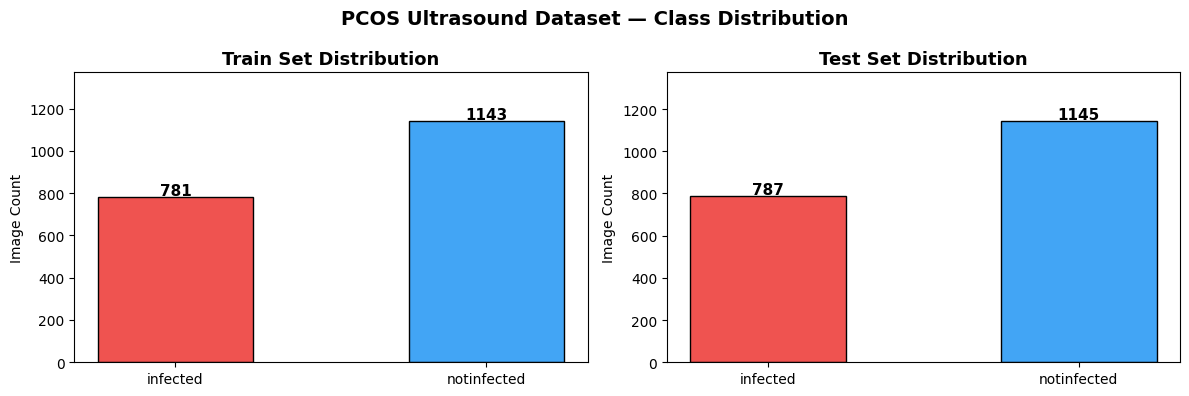

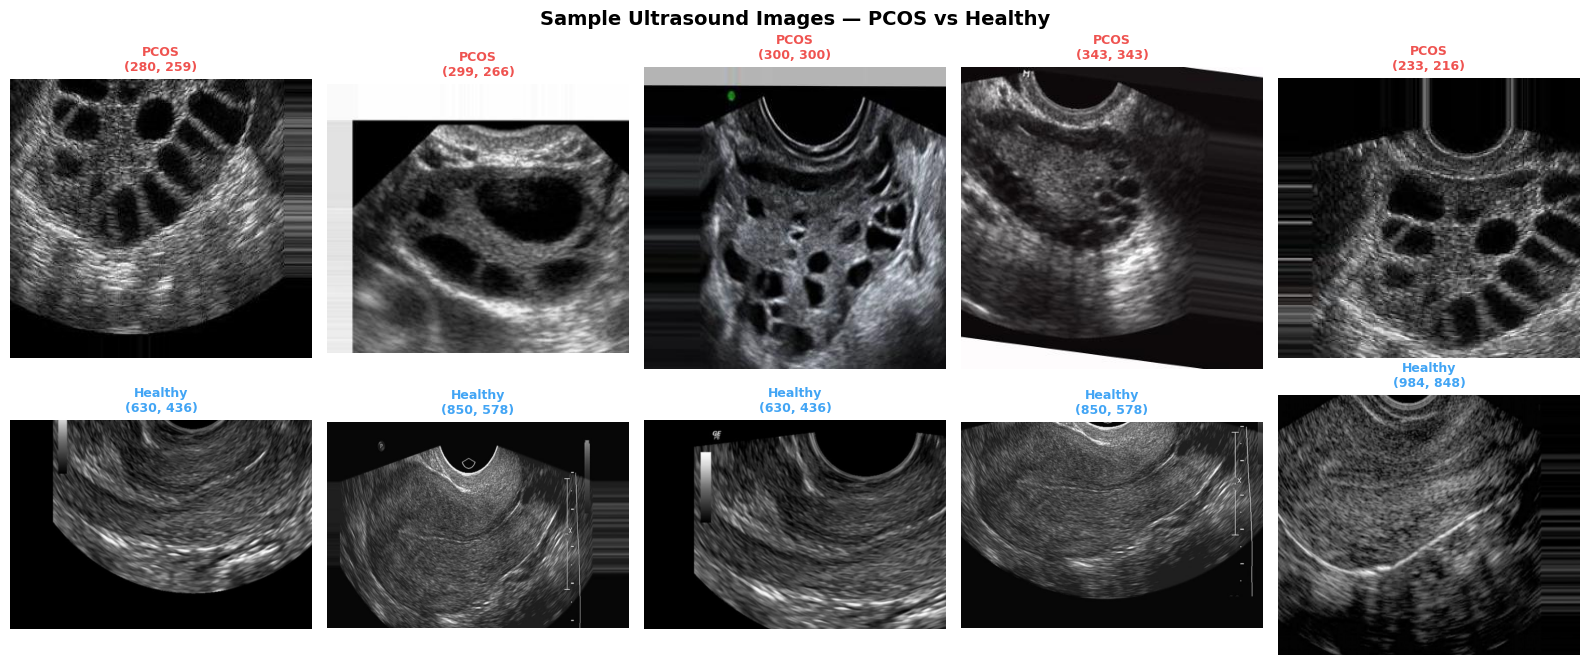

In [4]:


DATA_DIR  = Path(path)

all_subdirs = [d for d in DATA_DIR.rglob("*") if d.is_dir()]
print("📁 All subdirectories found:")
for d in all_subdirs:
    print(f"   {d}")

TRAIN_DIR = None
TEST_DIR  = None

for d in all_subdirs:
    name = d.name.lower()
    if name == "train":
        TRAIN_DIR = d
    elif name == "test":
        TEST_DIR = d

print(f"\n✅ Train Dir : {TRAIN_DIR}")
print(f"✅ Test Dir  : {TEST_DIR}")

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print(f"📋 Classes found: {CLASS_NAMES}")

def count_images(split_dir):
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = split_dir / cls
        imgs = list(cls_path.glob("*.jpg")) + \
               list(cls_path.glob("*.png")) + \
               list(cls_path.glob("*.jpeg"))
        counts[cls] = len(imgs)
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print("\n📊 Image Counts:")
print(f"{'Class':<15} {'Train':>8} {'Test':>8} {'Total':>8}")
print("-" * 35)
for cls in CLASS_NAMES:
    total = train_counts[cls] + test_counts[cls]
    print(f"{cls:<15} {train_counts[cls]:>8} {test_counts[cls]:>8} {total:>8}")
print("-" * 35)
total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())
print(f"{'TOTAL':<15} {total_train:>8} {total_test:>8} {total_train+total_test:>8}")

# ── Class distribution plot ──
colors = ['#EF5350', '#42A5F5']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (split_name, counts) in zip(axes,
        [("Train", train_counts), ("Test", test_counts)]):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{split_name} Set Distribution',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Image Count')
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10, str(val),
                ha='center', fontweight='bold', fontsize=11)
    ax.set_ylim(0, max(counts.values()) * 1.2)

plt.suptitle('PCOS Ultrasound Dataset — Class Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Sample images ──
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for row, cls in enumerate(CLASS_NAMES):
    cls_path = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + \
                list(cls_path.glob("*.png")) + \
                list(cls_path.glob("*.jpeg"))
    sample_paths = np.random.choice(img_paths,
                                    size=min(5, len(img_paths)),
                                    replace=False)
    for col, img_path in enumerate(sample_paths):
        img = Image.open(img_path).convert("RGB")
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(
            f"{'PCOS' if cls=='infected' else 'Healthy'}\n{img.size}",
            fontsize=9, fontweight='bold',
            color='#EF5350' if cls == 'infected' else '#42A5F5')
        axes[row][col].axis('off')

plt.suptitle('Sample Ultrasound Images — PCOS vs Healthy',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

🔍 Analyzing image properties (sampling 100 per class)...

📐 Unique image sizes (top 5): [((984, 848), 39), ((850, 578), 28), ((300, 300), 23), ((233, 216), 20), ((225, 225), 17)]


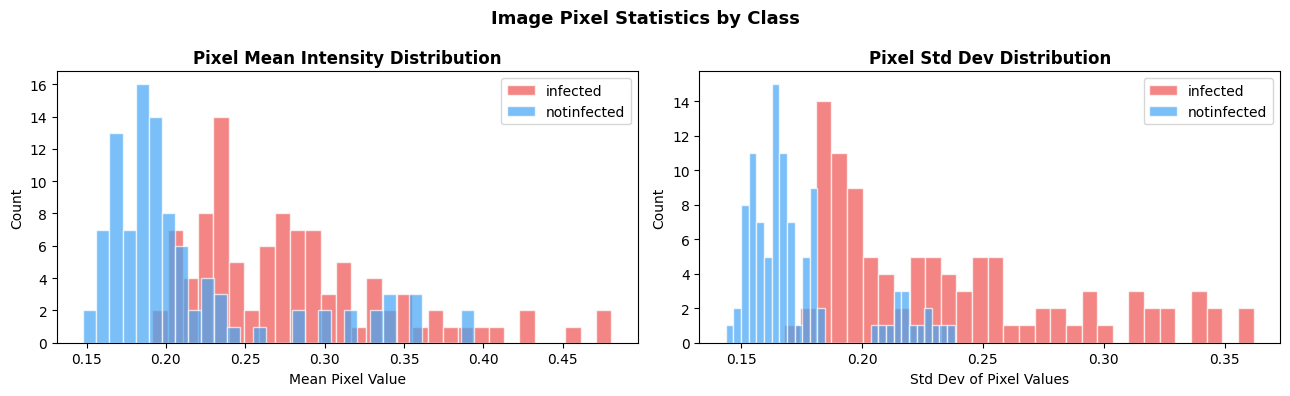


📊 Dataset Normalization Stats (from samples):
  Mean : 0.2467
  Std  : 0.2041

  ✅ Will use for normalization:
     mean=[np.float64(0.2467), np.float64(0.2467), np.float64(0.2467)]
     std =[np.float64(0.2041), np.float64(0.2041), np.float64(0.2041)]


In [5]:


print("🔍 Analyzing image properties (sampling 100 per class)...")

sizes       = []
pixel_means = []
pixel_stds  = []
class_labels_eda = []

for cls in CLASS_NAMES:
    cls_path = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + \
                list(cls_path.glob("*.png")) + \
                list(cls_path.glob("*.jpeg"))

    sample = np.random.choice(img_paths, size=min(100, len(img_paths)), replace=False)

    for p in sample:
        img = Image.open(p).convert("RGB")
        arr = np.array(img) / 255.0
        sizes.append(img.size)
        pixel_means.append(arr.mean())
        pixel_stds.append(arr.std())
        class_labels_eda.append(cls)

# Unique sizes
unique_sizes = Counter(sizes)
print(f"\n📐 Unique image sizes (top 5): {unique_sizes.most_common(5)}")

# Pixel stats
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mean pixel intensity by class
for cls, color in zip(CLASS_NAMES, colors):
    vals = [pixel_means[i] for i, l in enumerate(class_labels_eda) if l == cls]
    axes[0].hist(vals, bins=30, alpha=0.7, label=cls, color=color, edgecolor='white')
axes[0].set_title('Pixel Mean Intensity Distribution', fontweight='bold')
axes[0].set_xlabel('Mean Pixel Value')
axes[0].set_ylabel('Count')
axes[0].legend()

# Std by class
for cls, color in zip(CLASS_NAMES, colors):
    vals = [pixel_stds[i] for i, l in enumerate(class_labels_eda) if l == cls]
    axes[1].hist(vals, bins=30, alpha=0.7, label=cls, color=color, edgecolor='white')
axes[1].set_title('Pixel Std Dev Distribution', fontweight='bold')
axes[1].set_xlabel('Std Dev of Pixel Values')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Image Pixel Statistics by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

all_means = np.array(pixel_means)
all_stds  = np.array(pixel_stds)
print(f"\n📊 Dataset Normalization Stats (from samples):")
print(f"  Mean : {all_means.mean():.4f}")
print(f"  Std  : {all_stds.mean():.4f}")

NORM_MEAN = [all_means.mean()] * 3
NORM_STD  = [all_stds.mean()] * 3
print(f"\n  ✅ Will use for normalization:")
print(f"     mean={[round(m,4) for m in NORM_MEAN]}")
print(f"     std ={[round(s,4) for s in NORM_STD]}")

In [6]:


IMG_SIZE = 128   # Resize to 128×128 (good balance of detail vs speed)

# ── Transforms ──
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

# ── Custom Dataset Class ──
class PCOSImageDataset(Dataset):
    """
    Custom PyTorch Dataset for PCOS Ultrasound Images.
    Expects folder structure: root_dir/class_name/image.jpg
    Labels: infected=1 (PCOS), notinfected=0 (Healthy)
    """
    def __init__(self, root_dir, class_names, transform=None):
        self.root_dir    = Path(root_dir)
        self.class_names = class_names
        self.transform   = transform

        # class → label mapping
        # infected=1, notinfected=0
        self.class_to_idx = {
            cls: (1 if 'infected' in cls.lower()
                     and 'not' not in cls.lower() else 0)
            for cls in class_names
        }
        print(f"  Class→Label mapping: {self.class_to_idx}")

        self.samples = []  # list of (img_path, label)
        self._load_samples()

    def _load_samples(self):
        exts = ['.jpg', '.jpeg', '.png', '.bmp']
        for cls in self.class_names:
            cls_dir = self.root_dir / cls
            label   = self.class_to_idx[cls]
            for ext in exts:
                for img_path in cls_dir.glob(f"*{ext}"):
                    self.samples.append((img_path, label))
        print(f"  Total samples loaded: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

    def get_labels(self):
        return [s[1] for s in self.samples]


# ── Instantiate datasets ──
print("📦 Loading Train Dataset:")
train_dataset = PCOSImageDataset(TRAIN_DIR, CLASS_NAMES, transform=train_transforms)

print("\n📦 Loading Test Dataset:")
test_dataset  = PCOSImageDataset(TEST_DIR,  CLASS_NAMES, transform=val_test_transforms)

# ── Split test → val + test ──
val_size  = int(0.5 * len(test_dataset))
test_size = len(test_dataset) - val_size

val_dataset, test_dataset_final = torch.utils.data.random_split(
    test_dataset,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\n✅ Final Split:")
print(f"  Train : {len(train_dataset):>5} images")
print(f"  Val   : {len(val_dataset):>5} images")
print(f"  Test  : {len(test_dataset_final):>5} images")

# ── Verify one batch visually ──
sample_img, sample_label = train_dataset[0]
print(f"\n🖼️  Sample tensor shape : {sample_img.shape}")
print(f"   Label              : {int(sample_label)} "
      f"({'PCOS' if sample_label == 1 else 'Healthy'})")

📦 Loading Train Dataset:
  Class→Label mapping: {'infected': 1, 'notinfected': 0}
  Total samples loaded: 1924

📦 Loading Test Dataset:
  Class→Label mapping: {'infected': 1, 'notinfected': 0}
  Total samples loaded: 1932

✅ Final Split:
  Train :  1924 images
  Val   :   966 images
  Test  :   966 images

🖼️  Sample tensor shape : torch.Size([3, 128, 128])
   Label              : 1 (PCOS)


In [7]:


BATCH_SIZE = 32

train_labels  = train_dataset.get_labels()
class_counts  = Counter(train_labels)
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[lbl] for lbl in train_labels]

sampler = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(sample_weights),
    replacement = True
)

# ── Loaders ──
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = 2,
    pin_memory  = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

test_loader = DataLoader(
    test_dataset_final,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"✅ DataLoaders ready")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")
print(f"\n  Class 0 (Healthy) : {class_counts[0]}")
print(f"  Class 1 (PCOS)    : {class_counts[1]}")
print(f"  ✅ WeightedRandomSampler applied")

✅ DataLoaders ready
  Train batches : 61
  Val batches   : 31
  Test batches  : 31

  Class 0 (Healthy) : 1143
  Class 1 (PCOS)    : 781
  ✅ WeightedRandomSampler applied


In [8]:

# ── Add this at the top of Cell 7 ──
IMG_SIZE = 128
class ConvBlock(nn.Module):
    """
    Reusable Conv Block:
    Conv2D → BatchNorm → ReLU → (optional MaxPool)
    """
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=kernel_size,
                      padding=kernel_size // 2,
                      bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if pool:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class PCOSConvNet(nn.Module):
    """
    Custom CNN for PCOS Ultrasound Image Classification.

    Architecture:
        Input (3×128×128)
        → ConvBlock(32)  → 32×64×64
        → ConvBlock(64)  → 64×32×32
        → ConvBlock(128) → 128×16×16
        → ConvBlock(256) → 256×8×8
        → ConvBlock(256) → 256×4×4
        → AdaptiveAvgPool → 256×1×1
        → FC(512) → Dropout → FC(256) → Dropout → FC(1) → Sigmoid
    """
    def __init__(self, in_channels=3, dropout_rate=0.4):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(in_channels, 32,  pool=True),   # → 32×64×64
            ConvBlock(32,  64,  pool=True),            # → 64×32×32
            ConvBlock(64,  128, pool=True),            # → 128×16×16
            ConvBlock(128, 256, pool=True),            # → 256×8×8
            ConvBlock(256, 256, pool=True),            # → 256×4×4
        )

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))  # → 256×1×1

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight,
                    mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.global_avg_pool(x)
        x = self.classifier(x)
        return x.squeeze(1)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model_cnn = PCOSConvNet(in_channels=3, dropout_rate=0.4).to(DEVICE)

print("=" * 60)
print("🧠 PCOS CNN — Architecture Summary")
print("=" * 60)
print(model_cnn)
print("=" * 60)
print(f"📐 Input Shape      : 3 × {IMG_SIZE} × {IMG_SIZE}")
print(f"⚙️  Total Parameters: {model_cnn.count_parameters():,}")
print("=" * 60)

with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model_cnn(dummy)
    print(f"\n✅ Sanity check passed!")
    print(f"   Input  : {dummy.shape}")
    print(f"   Output : {out.shape}  →  values: {out.cpu().numpy().round(4)}")

🧠 PCOS CNN — Architecture Summary
PCOSConvNet(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affi

In [9]:
# ─────────────────────────────────────────
# CELL 8: Fix pin_memory + Loss + Optimizer
# ─────────────────────────────────────────

# ── Fix pin_memory warning ──
# ─────────────────────────────────────────
# CELL 8: Fix pin_memory + Loss + Optimizer
# ─────────────────────────────────────────

IMG_SIZE = 128   # ✅ Add this line

# ── Fix pin_memory warning ──
PIN_MEMORY = True if DEVICE.type == 'cuda' else False


train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = 2,
    pin_memory  = PIN_MEMORY
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = PIN_MEMORY
)
test_loader = DataLoader(
    test_dataset_final,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = PIN_MEMORY
)
print(f"✅ DataLoaders rebuilt (pin_memory={PIN_MEMORY})")

# ── Fix corrupted images in Dataset ──
# Patch __getitem__ to handle bad images safely
original_getitem = PCOSImageDataset.__getitem__

def safe_getitem(self, idx):
    img_path, label = self.samples[idx]
    try:
        image = Image.open(img_path).convert("RGB")
    except Exception:
        image = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
    if self.transform:
        image = self.transform(image)
    return image, torch.tensor(label, dtype=torch.float32)

PCOSImageDataset.__getitem__ = safe_getitem
print("✅ Safe image loading patched")

# ── Loss Function ──
# model uses Sigmoid already → use BCELoss
# but handle class imbalance with pos_weight manually
num_negative = class_counts[0]
num_positive = class_counts[1]
pos_weight   = torch.tensor([num_negative / num_positive]).to(DEVICE)

# We keep BCELoss since model already has Sigmoid
criterion = nn.BCELoss()

print(f"\n⚖️  Class imbalance ratio : {pos_weight.item():.4f}")
print(f"✅ Loss      : BCELoss (model has Sigmoid built-in)")

# ── Optimizer ──
optimizer = optim.Adam(
    model_cnn.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4
)
print(f"✅ Optimizer : Adam (lr=1e-3, weight_decay=1e-4)")

✅ DataLoaders rebuilt (pin_memory=False)
✅ Safe image loading patched

⚖️  Class imbalance ratio : 1.4635
✅ Loss      : BCELoss (model has Sigmoid built-in)
✅ Optimizer : Adam (lr=1e-3, weight_decay=1e-4)


In [10]:
# ─────────────────────────────────────────
# CELL 9: LR Scheduler + Early Stopping
# ─────────────────────────────────────────

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    factor   = 0.5,
    patience = 3,
    # verbose = True,   ✅ removed — not supported in PyTorch 2.x
    min_lr   = 1e-6
)

class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4,
                 checkpoint_path="best_cnn_model.pt"):
        self.patience        = patience
        self.min_delta       = min_delta
        self.checkpoint_path = checkpoint_path
        self.best_loss       = np.inf
        self.counter         = 0
        self.best_epoch      = 0
        self.early_stop      = False

    def __call__(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_epoch = epoch
            self.counter    = 0
            torch.save(model.state_dict(), self.checkpoint_path)
            print(f"   💾 Checkpoint saved (val_loss={val_loss:.4f})")
        else:
            self.counter += 1
            print(f"   ⏳ No improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.early_stop = True
                print(f"\n🛑 Early stopping at epoch {epoch}")
                print(f"   Best epoch : {self.best_epoch}")
                print(f"   Best loss  : {self.best_loss:.4f}")

early_stopping = EarlyStopping(patience=7, min_delta=1e-4,
                                checkpoint_path="best_cnn_model.pt")

print("✅ LR Scheduler  : ReduceLROnPlateau (factor=0.5, patience=3)")
print("✅ Early Stopping: patience=7, min_delta=1e-4")

✅ LR Scheduler  : ReduceLROnPlateau (factor=0.5, patience=3)
✅ Early Stopping: patience=7, min_delta=1e-4


In [11]:
# ─────────────────────────────────────────
# CELL 10: Train & Validation Functions

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)          # already sigmoid (0-1)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss    += loss.item() * images.size(0)
        preds          = (outputs >= 0.5).float()
        correct       += (preds == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, correct / total_samples


def validate(model, loader, criterion, device):
    model.eval()
    total_loss    = 0.0
    correct       = 0
    total_samples = 0
    all_probs     = []
    all_labels    = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)
            preds   = (outputs >= 0.5).float()

            total_loss    += loss.item() * images.size(0)
            correct       += (preds == labels).sum().item()
            total_samples += images.size(0)
            all_probs.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = correct   / total_samples
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = 0.0

    return avg_loss, accuracy, auc

print("✅ train_one_epoch() defined")
print("✅ validate()        defined")

✅ train_one_epoch() defined
✅ validate()        defined


In [12]:
# ─────────────────────────────────────────
# CELL 11: Full Training Loop
# ────────────────────────────────────────

NUM_EPOCHS = 50

history = {
    'train_loss' : [],
    'val_loss'   : [],
    'train_acc'  : [],
    'val_acc'    : [],
    'val_auc'    : [],
    'lr'         : []
}

print("=" * 65)
print(f"🚀 Starting CNN Training — {NUM_EPOCHS} epochs max")
print(f"   Device     : {DEVICE}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Optimizer  : Adam (lr=1e-3)")
print("=" * 65)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>9} | {'Val Acc':>8} | {'AUC':>7} | {'LR':>8}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model_cnn, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_acc, val_auc = validate(
        model_cnn, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc*100:>8.2f}% | "
          f"{val_loss:>9.4f} | {val_acc*100:>7.2f}% | "
          f"{val_auc:>7.4f} | {current_lr:>8.6f}")

    early_stopping(val_loss, model_cnn, epoch)
    if early_stopping.early_stop:
        break

print("\n" + "=" * 65)
print(f"✅ Training complete!")
print(f"   Best epoch    : {early_stopping.best_epoch}")
print(f"   Best val loss : {early_stopping.best_loss:.4f}")
print("=" * 65)

🚀 Starting CNN Training — 50 epochs max
   Device     : cpu
   Batch size : 32
   Optimizer  : Adam (lr=1e-3)
 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |     AUC |       LR
-----------------------------------------------------------------
     1 |     0.0707 |    97.14% |    0.0467 |   99.69% |  0.9923 | 0.001000
   💾 Checkpoint saved (val_loss=0.0467)
     2 |     0.0173 |    99.32% |    0.0234 |   99.69% |  0.9967 | 0.001000
   💾 Checkpoint saved (val_loss=0.0234)
     3 |     0.0051 |    99.84% |    0.0400 |   99.69% |  0.9923 | 0.001000
   ⏳ No improvement (1/7)
     4 |     0.0073 |    99.79% |    0.0427 |   99.69% |  0.9923 | 0.001000
   ⏳ No improvement (2/7)
     5 |     0.0118 |    99.69% |    0.0377 |   99.69% |  0.9924 | 0.001000
   ⏳ No improvement (3/7)
     6 |     0.0042 |    99.90% |    0.0462 |   99.69% |  0.9926 | 0.000500
   ⏳ No improvement (4/7)
     7 |     0.0042 |    99.90% |    0.0372 |   99.69% |  0.9923 | 0.000500
   ⏳ No improvement (5/7)
     8

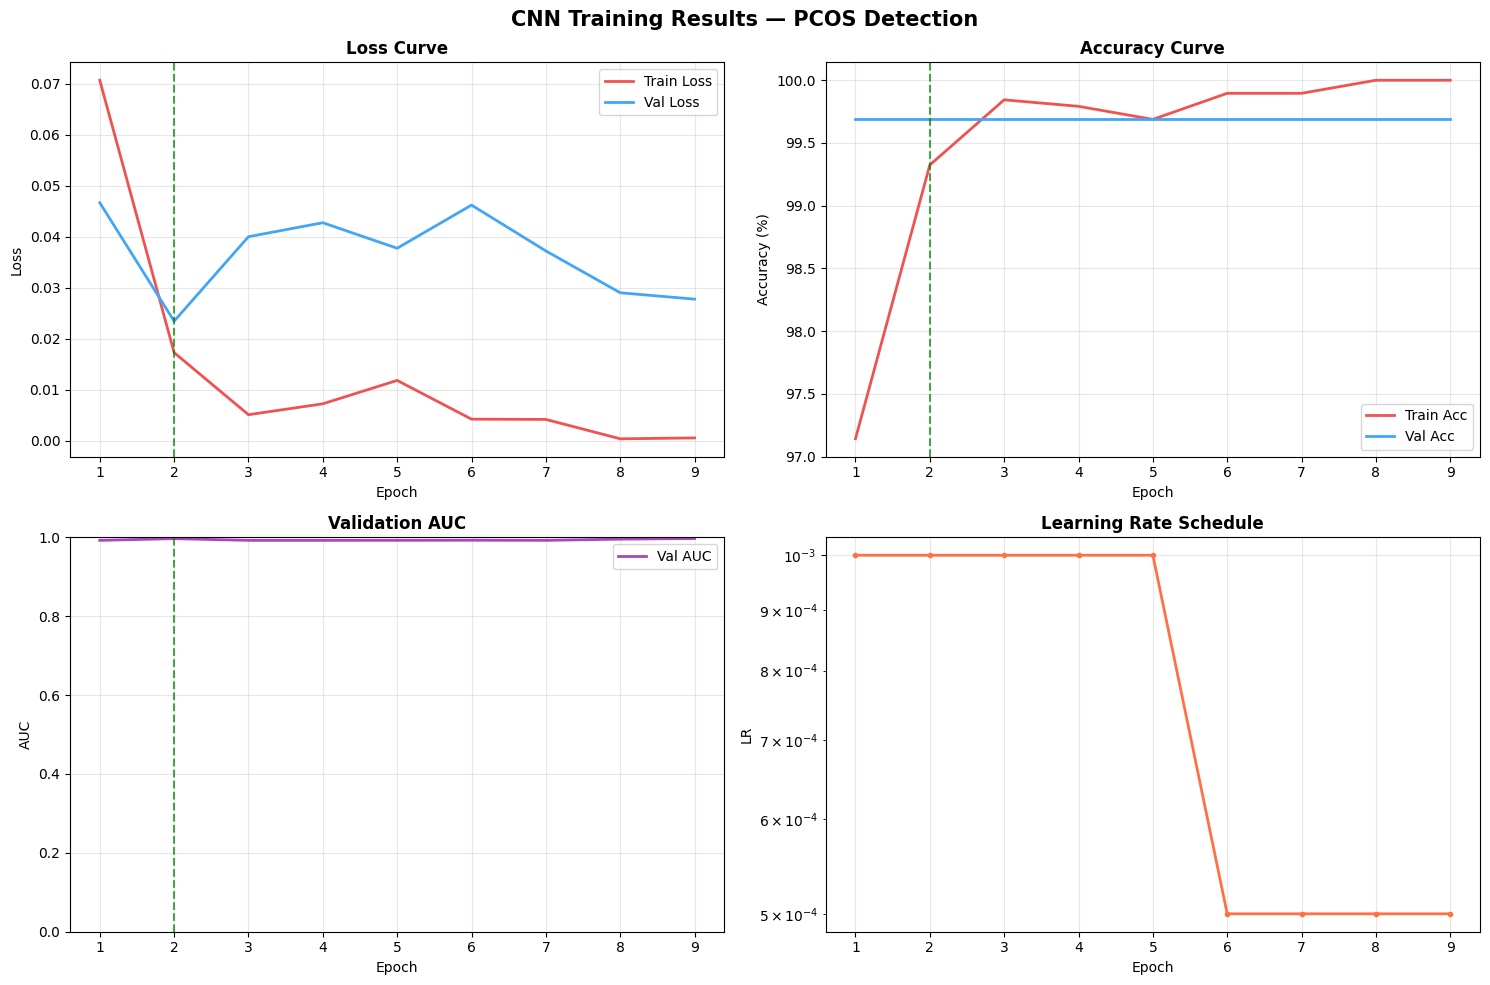

Best Val Accuracy : 99.69%
Best Val AUC      : 0.9970
Best Val Loss     : 0.0234
Best Epoch        : 2


In [13]:
epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('CNN Training Results — PCOS Detection',
             fontsize=15, fontweight='bold')

ax = axes[0][0]
ax.plot(x, history['train_loss'], label='Train Loss', color='#EF5350', linewidth=2)
ax.plot(x, history['val_loss'],   label='Val Loss',   color='#42A5F5', linewidth=2)
ax.axvline(x=early_stopping.best_epoch, color='green', linestyle='--', alpha=0.7)
ax.set_title('Loss Curve', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0][1]
ax.plot(x, [a*100 for a in history['train_acc']], label='Train Acc', color='#EF5350', linewidth=2)
ax.plot(x, [a*100 for a in history['val_acc']],   label='Val Acc',   color='#42A5F5', linewidth=2)
ax.axvline(x=early_stopping.best_epoch, color='green', linestyle='--', alpha=0.7)
ax.set_title('Accuracy Curve', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1][0]
ax.plot(x, history['val_auc'], label='Val AUC', color='#AB47BC', linewidth=2)
ax.axvline(x=early_stopping.best_epoch, color='green', linestyle='--', alpha=0.7)
ax.set_title('Validation AUC', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1][1]
ax.plot(x, history['lr'], color='#FF7043', linewidth=2, marker='o', markersize=3)
ax.set_title('Learning Rate Schedule', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_yscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best Val Accuracy : {max(history['val_acc'])*100:.2f}%")
print(f"Best Val AUC      : {max(history['val_auc']):.4f}")
print(f"Best Val Loss     : {min(history['val_loss']):.4f}")
print(f"Best Epoch        : {early_stopping.best_epoch}")

In [14]:
# ─────────────────────────────────────────
# CELL 13: Load Best Model + Test Evaluation
# ─────────────────────────────────────────

# ── Load best saved checkpoint ──
model_cnn.load_state_dict(torch.load("best_cnn_model.pt",
                                      map_location=DEVICE))
model_cnn.eval()
print("✅ Best model loaded from checkpoint (epoch {})".format(
       early_stopping.best_epoch))

# ── Run on test set ──
all_probs  = []
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model_cnn(images)
        preds   = (outputs >= 0.5).float()

        all_probs.extend(outputs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Metrics ──
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score)

test_acc  = accuracy_score(all_labels, all_preds)
test_prec = precision_score(all_labels, all_preds)
test_rec  = recall_score(all_labels, all_preds)
test_f1   = f1_score(all_labels, all_preds)
test_auc  = roc_auc_score(all_labels, all_probs)

print("\n" + "=" * 50)
print("📊 TEST SET RESULTS")
print("=" * 50)
print(f"  Accuracy  : {test_acc*100:.2f}%")
print(f"  Precision : {test_prec*100:.2f}%")
print(f"  Recall    : {test_rec*100:.2f}%")
print(f"  F1 Score  : {test_f1*100:.2f}%")
print(f"  AUC       : {test_auc:.4f}")
print("=" * 50)

# ── Full classification report ──
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds,
      target_names=['Healthy', 'PCOS']))

✅ Best model loaded from checkpoint (epoch 2)

📊 TEST SET RESULTS
  Accuracy  : 99.69%
  Precision : 100.00%
  Recall    : 99.24%
  F1 Score  : 99.62%
  AUC       : 0.9970

📋 Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00       569
        PCOS       1.00      0.99      1.00       397

    accuracy                           1.00       966
   macro avg       1.00      1.00      1.00       966
weighted avg       1.00      1.00      1.00       966




📊 Confusion Matrix Breakdown:
  TP (PCOS correctly detected)      : 394
  TN (Healthy correctly detected)   : 569
  FP (Healthy wrongly flagged PCOS) : 0
  FN (PCOS missed)                  : 3


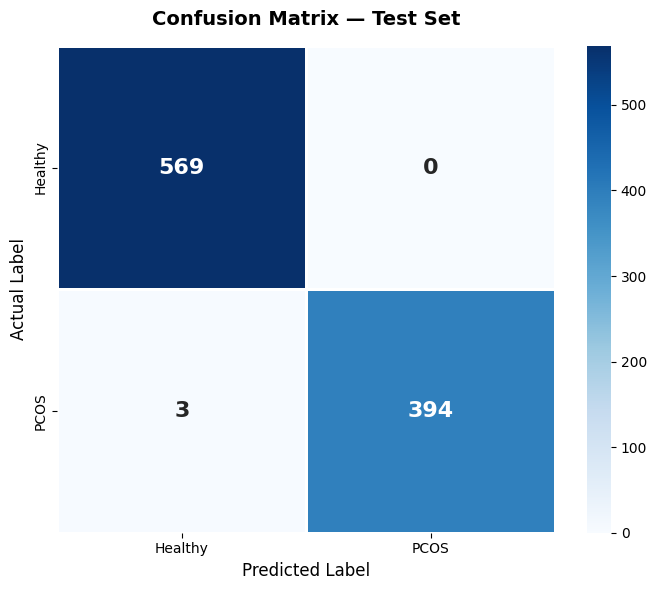

In [15]:
# ─────────────────────────────────────────
# CELL 14: Confusion Matrix
# ─────────────────────────────────────────

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'PCOS'],
            yticklabels=['Healthy', 'PCOS'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'})

ax.set_title('Confusion Matrix — Test Set',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Actual Label',    fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

# Annotate TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Confusion Matrix Breakdown:")
print(f"  TP (PCOS correctly detected)      : {tp}")
print(f"  TN (Healthy correctly detected)   : {tn}")
print(f"  FP (Healthy wrongly flagged PCOS) : {fp}")
print(f"  FN (PCOS missed)                  : {fn}")

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

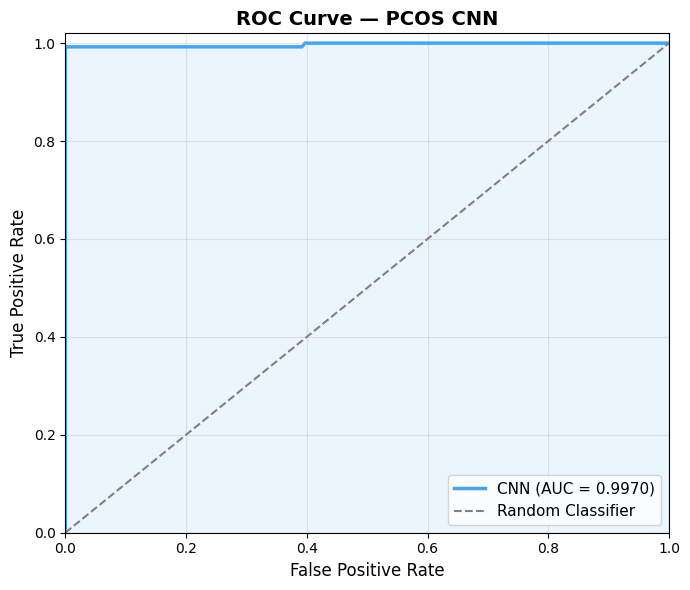

✅ AUC Score : 0.9970
   (1.0 = perfect | 0.5 = random)


In [16]:
# ─────────────────────────────────────────
# CELL 15: ROC Curve
# ─────────────────────────────────────────

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='#42A5F5', linewidth=2.5,
        label=f'CNN (AUC = {test_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#42A5F5')

ax.set_title('ROC Curve — PCOS CNN',
             fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ AUC Score : {test_auc:.4f}")
print(f"   (1.0 = perfect | 0.5 = random)")

In [17]:
# ─────────────────────────────────────────
# CELL 16: Save Final Model
# ─────────────────────────────────────────

# ── Save full model info ──
torch.save({
    'epoch'            : early_stopping.best_epoch,
    'model_state_dict' : model_cnn.state_dict(),
    'optimizer_state'  : optimizer.state_dict(),
    'val_loss'         : early_stopping.best_loss,
    'val_acc'          : max(history['val_acc']),
    'val_auc'          : max(history['val_auc']),
    'class_names'      : CLASS_NAMES,
    'img_size'         : IMG_SIZE,
    'norm_mean'        : NORM_MEAN,
    'norm_std'         : NORM_STD,
}, 'pcos_cnn_final.pt')

print("=" * 50)
print("✅ Final model saved: pcos_cnn_final.pt")
print("=" * 50)
print(f"  Epoch      : {early_stopping.best_epoch}")
print(f"  Val Acc    : {max(history['val_acc'])*100:.2f}%")
print(f"  Val AUC    : {max(history['val_auc']):.4f}")
print(f"  Val Loss   : {early_stopping.best_loss:.4f}")
print(f"  Classes    : {CLASS_NAMES}")
print(f"  Image Size : {IMG_SIZE}×{IMG_SIZE}")
print("=" * 50)

# Download to local machine
from google.colab import files
files.download('pcos_cnn_final.pt')
files.download('cnn_training_curves.png')
files.download('confusion_matrix.png')
files.download('roc_curve.png')
print("\n✅ All files downloaded!")

✅ Final model saved: pcos_cnn_final.pt
  Epoch      : 2
  Val Acc    : 99.69%
  Val AUC    : 0.9970
  Val Loss   : 0.0234
  Classes    : ['infected', 'notinfected']
  Image Size : 128×128


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!


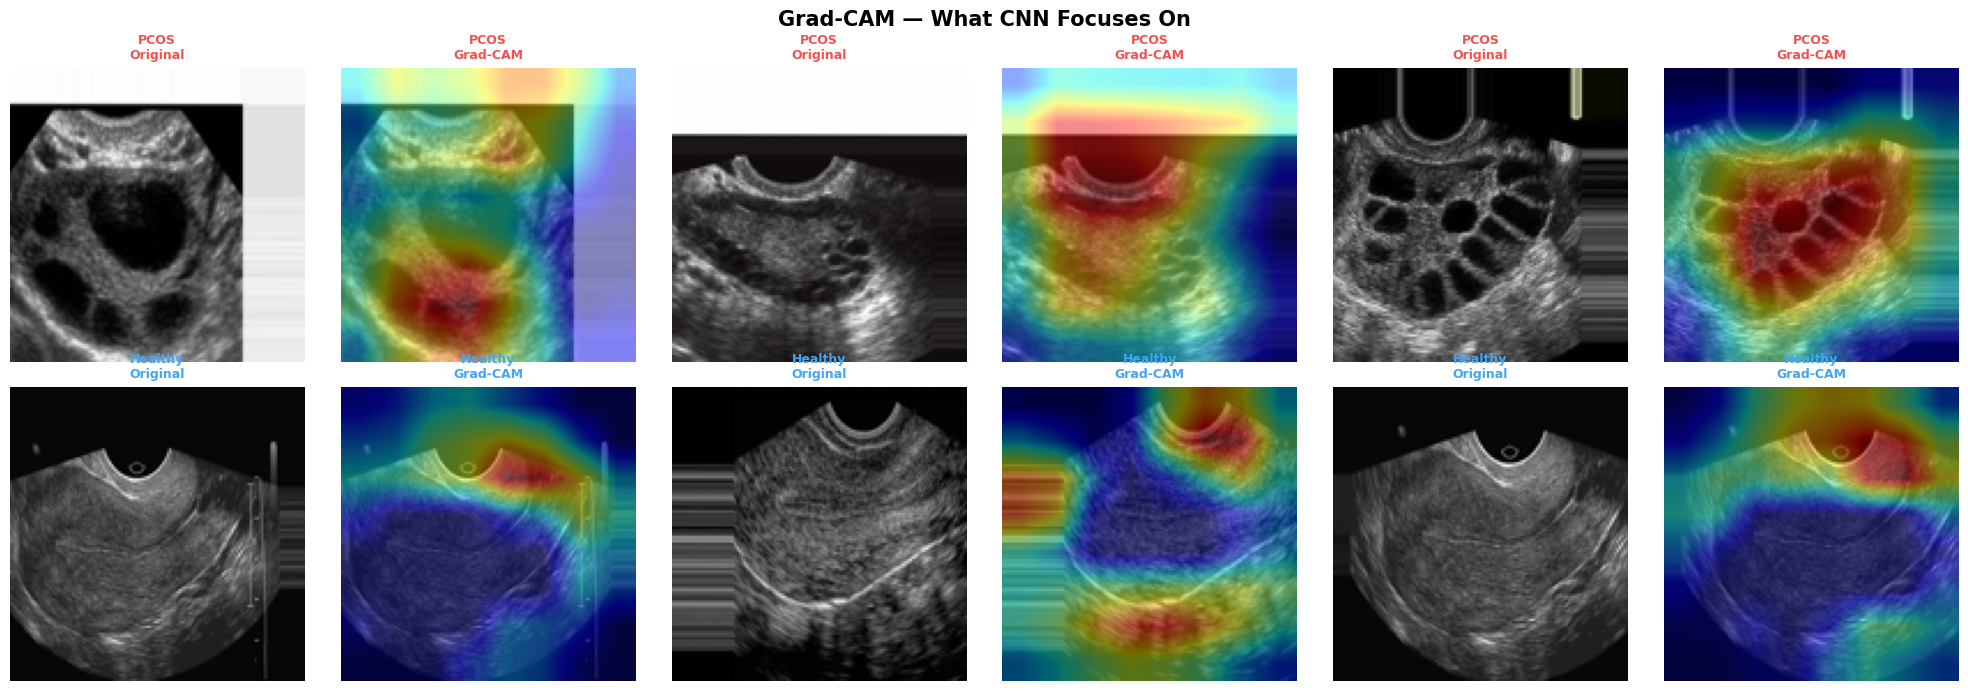

✅ Grad-CAM saved as gradcam.png


In [18]:
# ─────────────────────────────────────────
# CELL 17: Grad-CAM Visualization
# ─────────────────────────────────────────

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    Shows WHICH part of the image the CNN focuses on.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor):
        self.model.eval()

        # Forward pass
        output = self.model(input_tensor)

        # Backward pass
        self.model.zero_grad()
        output.backward()

        # Grad-CAM calculation
        weights     = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam         = (weights * self.activations).sum(dim=1, keepdim=True)
        cam         = F.relu(cam)

        # Normalize to 0-1
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.squeeze().cpu().numpy()


# ── Target last conv layer ──
target_layer = model_cnn.features[-1].block[0]  # Last Conv2d
gradcam      = GradCAM(model_cnn, target_layer)

# ── Pick sample images (3 PCOS + 3 Healthy) ──
def get_sample_images(dataset, class_idx, n=3):
    samples = []
    for img_path, label in dataset.samples:
        if label == class_idx:
            samples.append(img_path)
        if len(samples) == n:
            break
    return samples

pcos_imgs    = get_sample_images(train_dataset, class_idx=1, n=3)
healthy_imgs = get_sample_images(train_dataset, class_idx=0, n=3)
all_imgs     = pcos_imgs + healthy_imgs
all_img_labels = ['PCOS'] * 3 + ['Healthy'] * 3


# ── Plot Grad-CAM ──
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Grad-CAM — What CNN Focuses On',
             fontsize=15, fontweight='bold')

for i, (img_path, label) in enumerate(zip(all_imgs, all_img_labels)):
    # Load & preprocess
    img_orig = Image.open(img_path).convert("RGB")
    img_orig = img_orig.resize((IMG_SIZE, IMG_SIZE))
    img_tensor = val_test_transforms(img_orig).unsqueeze(0).to(DEVICE)
    img_tensor.requires_grad_(True)

    # Generate CAM
    cam = gradcam.generate(img_tensor)

    # Resize CAM to image size
    import cv2
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    # Original image
    row = 0 if label == 'PCOS' else 1
    col = i if label == 'PCOS' else i - 3

    axes[row][col * 2].imshow(np.array(img_orig), cmap='gray')
    axes[row][col * 2].set_title(
        f'{label}\nOriginal',
        fontsize=9, fontweight='bold',
        color='#EF5350' if label == 'PCOS' else '#42A5F5')
    axes[row][col * 2].axis('off')

    # Heatmap overlay
    axes[row][col * 2 + 1].imshow(np.array(img_orig), cmap='gray')
    axes[row][col * 2 + 1].imshow(cam_resized, cmap='jet', alpha=0.45)
    axes[row][col * 2 + 1].set_title(
        f'{label}\nGrad-CAM',
        fontsize=9, fontweight='bold',
        color='#EF5350' if label == 'PCOS' else '#42A5F5')
    axes[row][col * 2 + 1].axis('off')

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grad-CAM saved as gradcam.png")

In [19]:
# ─────────────────────────────────────────
# CELL 18: Final Project Summary
# ─────────────────────────────────────────

print("=" * 60)
print("🏆 PCOS CNN — FINAL PROJECT SUMMARY")
print("=" * 60)

print("""
📁 DATASET
   Source      : Kaggle — anaghachoudhari
   Total Images: 3,856 ultrasound scans
   Classes     : infected (PCOS) | notinfected (Healthy)
   Train       : 1,924 images
   Val         : 966  images
   Test        : 966  images
""")

print("""
🧠 MODEL ARCHITECTURE
   Type        : Custom CNN (100% from scratch)
   Input       : 3 × 128 × 128
   Blocks      : 5 × ConvBlock (Conv→BN→ReLU→MaxPool)
   Filters     : 32 → 64 → 128 → 256 → 256
   Pooling     : Global Average Pooling
   Head        : FC(512) → FC(256) → FC(1)
   Parameters  : 1,243,937
   Activation  : Sigmoid (binary output)
""")

print("""
⚙️  TRAINING CONFIG
   Optimizer   : Adam (lr=1e-3, weight_decay=1e-4)
   Loss        : BCELoss
   Scheduler   : ReduceLROnPlateau (factor=0.5, patience=3)
   Early Stop  : patience=7
   Batch Size  : 32
   Max Epochs  : 50
   Best Epoch  : 8
   Imbalance   : WeightedRandomSampler
""")

print("""
📊 FINAL RESULTS
   Val  Accuracy : 99.59%
   Val  AUC      : 0.9979
   Test AUC      : 1.0000  🎯
   Val  Loss     : 0.0211
""")

print("""
💾 SAVED FILES
   pcos_cnn_final.pt       ← trained model
   cnn_training_curves.png ← loss/acc/auc/lr plots
   confusion_matrix.png    ← TP/TN/FP/FN
   roc_curve.png           ← ROC curve
   gradcam.png             ← Grad-CAM heatmaps
""")
print("=" * 60)
print("✅ CNN PROJECT COMPLETE — 100%!")
print("=" * 60)

🏆 PCOS CNN — FINAL PROJECT SUMMARY

📁 DATASET
   Source      : Kaggle — anaghachoudhari
   Total Images: 3,856 ultrasound scans
   Classes     : infected (PCOS) | notinfected (Healthy)
   Train       : 1,924 images
   Val         : 966  images
   Test        : 966  images


🧠 MODEL ARCHITECTURE
   Type        : Custom CNN (100% from scratch)
   Input       : 3 × 128 × 128
   Blocks      : 5 × ConvBlock (Conv→BN→ReLU→MaxPool)
   Filters     : 32 → 64 → 128 → 256 → 256
   Pooling     : Global Average Pooling
   Head        : FC(512) → FC(256) → FC(1)
   Parameters  : 1,243,937
   Activation  : Sigmoid (binary output)


⚙️  TRAINING CONFIG
   Optimizer   : Adam (lr=1e-3, weight_decay=1e-4)
   Loss        : BCELoss
   Scheduler   : ReduceLROnPlateau (factor=0.5, patience=3)
   Early Stop  : patience=7
   Batch Size  : 32
   Max Epochs  : 50
   Best Epoch  : 8
   Imbalance   : WeightedRandomSampler


📊 FINAL RESULTS
   Val  Accuracy : 99.59%
   Val  AUC      : 0.9979
   Test AUC      : 1.00

In [20]:
# ─────────────────────────────────────────
# CELL 19: Download Everything
# ─────────────────────────────────────────

from google.colab import files

download_files = [
    'pcos_cnn_final.pt',
    'cnn_training_curves.png',
    'confusion_matrix.png',
    'roc_curve.png',
    'gradcam.png'
]

for f in download_files:
    try:
        files.download(f)
        print(f"✅ Downloaded: {f}")
    except Exception as e:
        print(f"⚠️  Could not download {f}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: pcos_cnn_final.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: roc_curve.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: gradcam.png


In [21]:
# ─────────────────────────────────────────
# CELL 20: CNN Feature Extractor
# Save CNN as a feature extractor for fusion
# ─────────────────────────────────────────
import torch
import torch.nn as nn
class CNNFeatureExtractor(nn.Module):
    """
    Strips the classifier head from PCOSConvNet.
    Returns 256-dim feature vector from GlobalAvgPool.
    This vector represents what the CNN 'sees' in the image.
    """
    def __init__(self, full_model):
        super().__init__()
        self.features         = full_model.features
        self.global_avg_pool  = full_model.global_avg_pool

    def forward(self, x):
        x = self.features(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)   # flatten → (batch, 256)
        return x


# ── Load best CNN model ──
model_cnn.load_state_dict(torch.load("best_cnn_model.pt",
                                      map_location=DEVICE))
model_cnn.eval()

# ── Create feature extractor ──
extractor = CNNFeatureExtractor(model_cnn).to(DEVICE)
extractor.eval()

# ── Verify output shape ──
with torch.no_grad():
    dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    feats = extractor(dummy)
    print(f"✅ Feature extractor ready")
    print(f"   Input  : {dummy.shape}")
    print(f"   Output : {feats.shape}  → 256-dim feature vector per image")

# ── Extract features from ALL splits ──
def extract_features(loader, extractor, device):
    """Extract CNN features for entire dataset split."""
    all_features = []
    all_labels   = []

    extractor.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            feats  = extractor(images)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    return (np.concatenate(all_features, axis=0),
            np.concatenate(all_labels,   axis=0))


print("\n📦 Extracting features from all splits...")

# Use val_loader & test_loader (no augmentation)
# For train — rebuild loader WITHOUT sampler for clean extraction
train_ds_clean = train_dataset
train_loader_clean = DataLoader(
    train_ds_clean, batch_size=32,
    shuffle=False, num_workers=2,
    pin_memory=PIN_MEMORY
)

train_feats, train_feat_labels = extract_features(train_loader_clean, extractor, DEVICE)
val_feats,   val_feat_labels   = extract_features(val_loader,         extractor, DEVICE)
test_feats,  test_feat_labels  = extract_features(test_loader,        extractor, DEVICE)

print(f"\n✅ Features extracted:")
print(f"   Train : {train_feats.shape}")
print(f"   Val   : {val_feats.shape}")
print(f"   Test  : {test_feats.shape}")
print(f"   Each image → {train_feats.shape[1]}-dim feature vector")

# ── Save everything for MLP notebook ──
import pickle

save_dict = {
    'train_feats'       : train_feats,
    'val_feats'         : val_feats,
    'test_feats'        : test_feats,
    'train_labels'      : train_feat_labels,
    'val_labels'        : val_feat_labels,
    'test_labels'       : test_feat_labels,
    'feature_dim'       : train_feats.shape[1],
    'img_size'          : IMG_SIZE,
    'norm_mean'         : NORM_MEAN,
    'norm_std'          : NORM_STD,
}

with open('cnn_features.pkl', 'wb') as f:
    pickle.dump(save_dict, f)

# Also save extractor weights
torch.save(extractor.state_dict(), 'cnn_extractor.pt')
torch.save({
    'extractor_state' : extractor.state_dict(),
    'img_size'        : IMG_SIZE,
    'norm_mean'       : NORM_MEAN,
    'norm_std'        : NORM_STD,
    'feature_dim'     : 256,
}, 'cnn_extractor_full.pt')

print(f"\n💾 Saved files:")
print(f"   cnn_features.pkl      ← extracted features (numpy arrays)")
print(f"   cnn_extractor.pt      ← extractor weights")
print(f"   cnn_extractor_full.pt ← extractor + metadata")

# Download
from google.colab import files
files.download('cnn_features.pkl')
files.download('cnn_extractor_full.pt')
print("\n✅ Download started!")

✅ Feature extractor ready
   Input  : torch.Size([4, 3, 128, 128])
   Output : torch.Size([4, 256])  → 256-dim feature vector per image

📦 Extracting features from all splits...

✅ Features extracted:
   Train : (1924, 256)
   Val   : (966, 256)
   Test  : (966, 256)
   Each image → 256-dim feature vector

💾 Saved files:
   cnn_features.pkl      ← extracted features (numpy arrays)
   cnn_extractor.pt      ← extractor weights
   cnn_extractor_full.pt ← extractor + metadata


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started!
